# Plot CTD profiles

In [1]:
import os
import netCDF4
import numpy as np
import xarray as xr
#import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcol

%matplotlib widget 

### Parameters

Specify the path to the data folder and the date of the campaign:

In [2]:
date_campaign='20250115'
data_folder=os.path.join('../data/CTD',date_campaign,'Level1')

Specify a specific file to plot with chosen variables:

In [3]:
filename = "L1_CTD_sea&sun_J1151606_1_20250115_112654.nc"
varnames_oneprof=["Temp","Cond","sat","Turb","pH","SALIN","rho"]

Specify the index of the background profile (to plot it at the end):

In [4]:
ind_background=0

Specify the indices of the profiles to plot (leave empty to plot all the profiles) and the variables:

In [5]:
profname_select=[]
#profname_select=['TZ1','TZ5','TZ6','TZ7','TZ8']
varnames_multiprof=["Temp", "Cond20", "sat","Turb"]
xlabel_multiprof=["Temperature (°C)","Conductivity at 20$^{\circ}$C (mS/cm)","Oxygen saturation (%)","Turbidity (FTU)"]

Specify the layers to remove at the top and bottom of the profiles:

In [6]:
dz_top=0.5 # [m], to remove near the surface
dz_bot=0.5 # [m], to remove at the bottom

Estimation of conductivity at 20°C:

In [7]:
cond20=lambda T, C: (1.684 - 0.04645*T + 0.000602*T**2)*C # T in [°C], C in [mS/cm]

### 1. Plot a specific profile

['time', 'Press', 'Temp', 'Cond', 'Chl_A', 'Turb', 'pH', 'sat', 'DO_mg', 'Flur', 'time_qual', 'Press_qual', 'Temp_qual', 'Cond_qual', 'Chl_A_qual', 'Turb_qual', 'pH_qual', 'sat_qual', 'DO_mg_qual', 'Flur_qual', 'rho', 'depth', 'pt', 'prho', 'thorpe', 'SALIN']


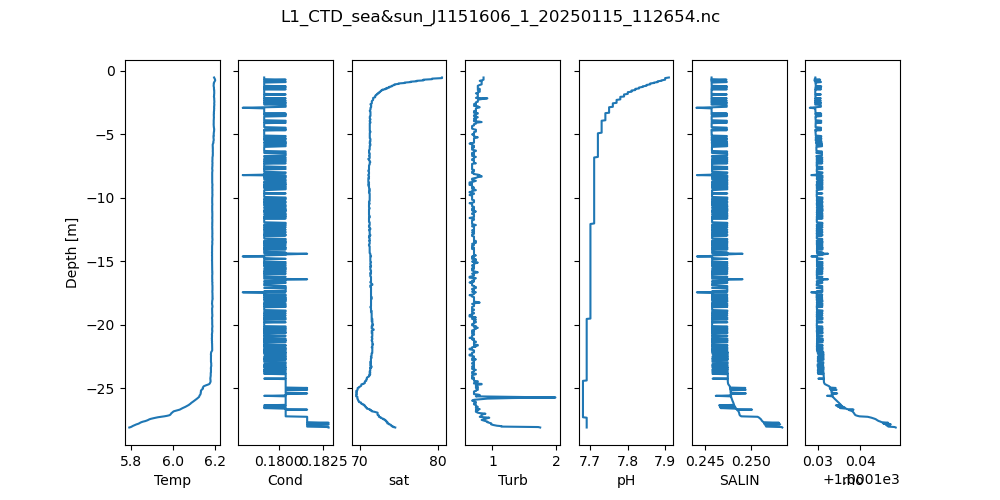

In [8]:
file = os.path.join(data_folder,filename)
nc=netCDF4.Dataset(file)
print(list(nc.variables)) # All variables

fig, ax = plt.subplots(1, len(varnames_oneprof), figsize=(10, 5),sharey=True)
Depthval=nc.variables["depth"][:]
for kv in range(len(varnames_oneprof)): 
    Varval=nc.variables[varnames_oneprof[kv]][:]
    if varnames_oneprof[kv]+"_qual" in nc.variables:
        Varval[nc.variables[varnames_oneprof[kv]+"_qual"][:]>0]=np.nan
    Varval[Depthval<dz_top]=np.nan
    Varval[Depthval>(np.nanmax(Depthval)-dz_bot)]=np.nan
    ax[kv].plot(Varval,-Depthval)
    ax[kv].set_xlabel(varnames_oneprof[kv])
ax[0].set_ylabel('Depth [m]')
fig.suptitle(filename)
nc.close()

### 2. Plot different profiles on same plots

In [9]:
files_all=[os.path.join(data_folder,f) for f in os.listdir(data_folder)]

Sort the profiles chronologically:

In [10]:
tnum_all=[]
files_nc=[]
prof_names=[]
for kf in range(len(files_all)):
    if ".nc" in files_all[kf]:
        with netCDF4.Dataset(files_all[kf]) as nc:
            tnum_all.append(nc.variables["time"][:].data[0])
            files_nc.append(files_all[kf])
            prof_names.append(getattr(nc, "Profile name"))
ind_sort=np.argsort(np.array(tnum_all))
files=[files_nc[i] for i in ind_sort]
prof_names=[prof_names[i] for i in ind_sort]

Move the background profile to the end of the series

In [11]:
files=files+[files[ind_background]]
_=files.pop(ind_background)
prof_names=prof_names+[prof_names[ind_background]]
_=prof_names.pop(ind_background)


Make the figure:

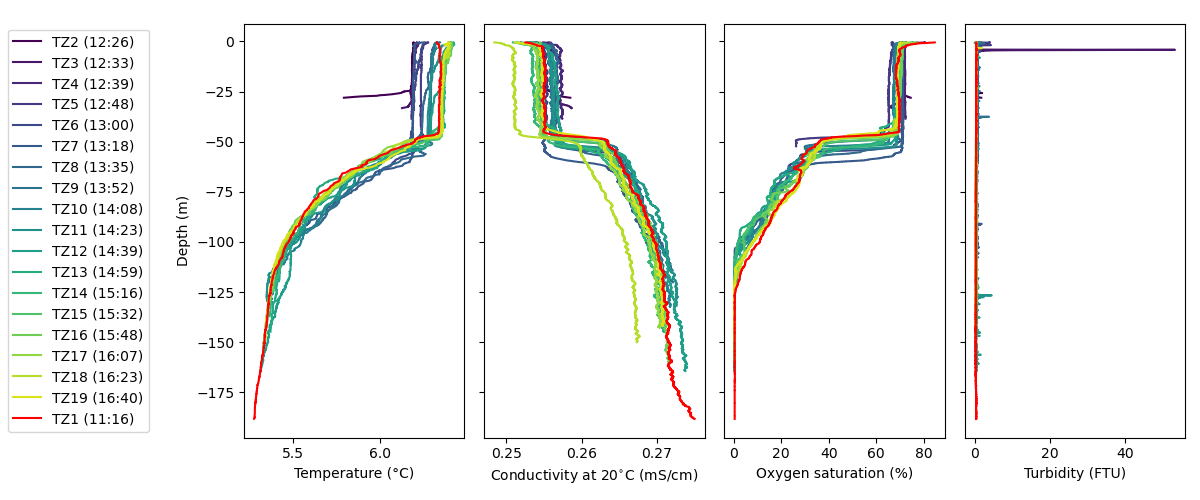

In [12]:
leg=[]
if profname_select==[]:
    ind_select=np.arange(len(files))
else:
    ind_select=np.array([i for i in range(len(prof_names)) if prof_names[i] in profname_select])
Cmap=plt.get_cmap('viridis',len(ind_select))
colors = Cmap(np.linspace(0, 1, len(ind_select)))
colors[-1] = [1,0,0,1]  # Color for the background profile
Cmap = mcol.ListedColormap(colors)
counter=-1

fig, ax = plt.subplots(1, len(varnames_multiprof), figsize=(12, 5),sharey=True)

for file in files:    
    if file in [files[i] for i in ind_select]:
        if ".nc" in file:
            counter+=1
            with netCDF4.Dataset(file) as nc:
                d = np.array(nc.variables["depth"][:])
                # d = np.array(nc.variables["Press"][:])
                for i, var in enumerate(varnames_multiprof):
                    if var=="Cond20":
                        v=cond20(np.array(nc.variables["Temp"][:]),np.array(nc.variables["Cond"][:])) # Cond at 20°C
                    else:
                        v = np.array(nc.variables[var][:])
                    if var=="SALIN" or var=="Cond" or var=="Cond20":
                        v = pd.Series(v).rolling(window=50, min_periods=1).mean().values # Moving average to smoothen the data
                    if var + "_qual" in nc.variables:
                        q = np.array(nc.variables[var + "_qual"][:])
                        v[q > 0] = np.nan
                    dmax=np.nanmax(d)
                    v[d>dmax-dz_bot]=np.nan # Remove bottom meter
                    v[d<dz_top]=np.nan # Remove top meter
                    ax[i].plot(v, -d,color=Cmap(counter))
                leg.append(getattr(nc, "Profile name")+" ("+getattr(nc, "Time of measurement (local)")+")")
ax[0].legend(leg,bbox_to_anchor=(-0.4,0.5),loc="center right")
ax[0].set_ylabel('Depth (m)')
# ax[0].set_ylabel('Pressure (dbar)')
for kax in range(len(varnames_multiprof)):
    ax[kax].set_xlabel(xlabel_multiprof[kax])
fig.set_tight_layout(True)

Export the figure

In [13]:
fig.savefig(os.path.join("Figures_CTD","profiles_transect.png"),dpi=400)